<a href="https://colab.research.google.com/github/BillieBurden/digital-history-2026/blob/main/Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# My hypothesis
The Federal Indian boarding school system expanded unevenly across the United States, with the Southwest and Plains states bearing a disproportionate share of schools. New school openings surged following the Dawes Act in 1887, sustaining high levels through the 1880s and 1890s, before declining after the Indian Reorganization Act in 1934.


In [22]:
#load the data- I'm using my original dataset that I cleaned for milestone #1 but I had to go back and add a dash between 3 sets of dates.
#so this is a new file which is why it says fixed
import pandas as pd
df = pd.read_csv('schools_cleaned_fixed.csv')

In [23]:
#making sure the data loaded in correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   School             418 non-null    object
 1   State              418 non-null    object
 2   operation_dates    411 non-null    object
 3   tribes_identified  418 non-null    object
 4   DOI deceased       418 non-null    int64 
 5   WP deceased        418 non-null    int64 
 6   DOI burial sites   65 non-null     object
 7   WP burial sites    57 non-null     object
 8   other_names        362 non-null    object
 9   Latitude           404 non-null    object
 10  Longitude          404 non-null    object
 11  Verified           404 non-null    object
dtypes: int64(2), object(10)
memory usage: 39.3+ KB


In [24]:
#I actually don't think this is necessary for my argument. At least not the information is is giving me.
df.describe()

,DOI deceased,WP deceased
count,418.000000,418.000000
mean,2.387560,7.425837
std,10.614819,22.473336
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,6.000000
max,189.000000,268.000000


In [27]:
#there are a few lines in my data that missing operation dates that I need to clean.
#'Subset' means that it doesn't delete all of the blank cells in the data.
#it failed the first time because I need to do dropna not drop. This is because I am looking for the missing values.
#interesting note is that the missing values for this column are primarily (6/7) from arizona
df = df.dropna(subset=['operation_dates'])

#there are some schools that have multiple dates that seem like there was a change of some sort and I don't want to get rid of them
#however because there are so few and I am looking at when the system expanded having all of the dates wouldn't add a meaning shift in data
#So I am splitting the dates to keep the first open and closed dates
df['operation_dates'] = df['operation_dates'].str.split('|')
df['operation_dates'] = df['operation_dates'].str[0]
#need to take additional spaces out so I can refer to just the numbers without unnecessary spaces.
df['operation_dates'] = df['operation_dates'].str.strip()

#then I want to separate the open year from the closed year. I'm doing this by splitting the dates at the dash.
df['open_year'] = df['operation_dates'].str.split('-')
df['open_year'] = df['open_year'].str[0]
#need to change the strings to numbers so I can work with them easier.
#the coerce means that it will leave it blank if it can't change it instead of giving an error.
df['open_year'] = pd.to_numeric(df['open_year'], errors='coerce').astype(int)#this takes away the decimal point at the end

#now I do the same thing for closing dates
df['close_year'] = df['operation_dates'].str.split('-')
df['close_year'] = df['close_year'].str[1]
df['close_year'] = pd.to_numeric(df['close_year'], errors = 'coerce').fillna(2024).astype(int)#year when this was last checked

#check to see if it works
df[['School', 'operation_dates', 'open_year', 'close_year']].head(10)

#commenting because I proud I just did all of that

,School,operation_dates,open_year,close_year
0,Chemawa Indian Training School,1880 - Open,1880,2024
1,Carlisle Indian Industrial School,1879 - 1918,1879,1918
2,Haskell Indian Industrial Training School,1884 - Open,1884,2024
3,Fort Hall Boarding School,1874 - 1936,1874,1936
4,"Sherman Institute: Riverside, CA",1902 - Open,1902,2024
5,Mount Pleasant Indian Industrial Boarding School,1893 - 1934,1893,1934
6,Albuquerque Indian School,1882 - 1982,1882,1982
7,Fort Defiance Boarding School,1881 - 1959,1881,1959
8,Stewart Indian Boarding School,1890 - 1980,1890,1980
9,Genoa Indian Industrial School,1884 - 1934,1884,1934


# Visualization to show the argument

<function matplotlib.pyplot.show(close=None, block=None)>

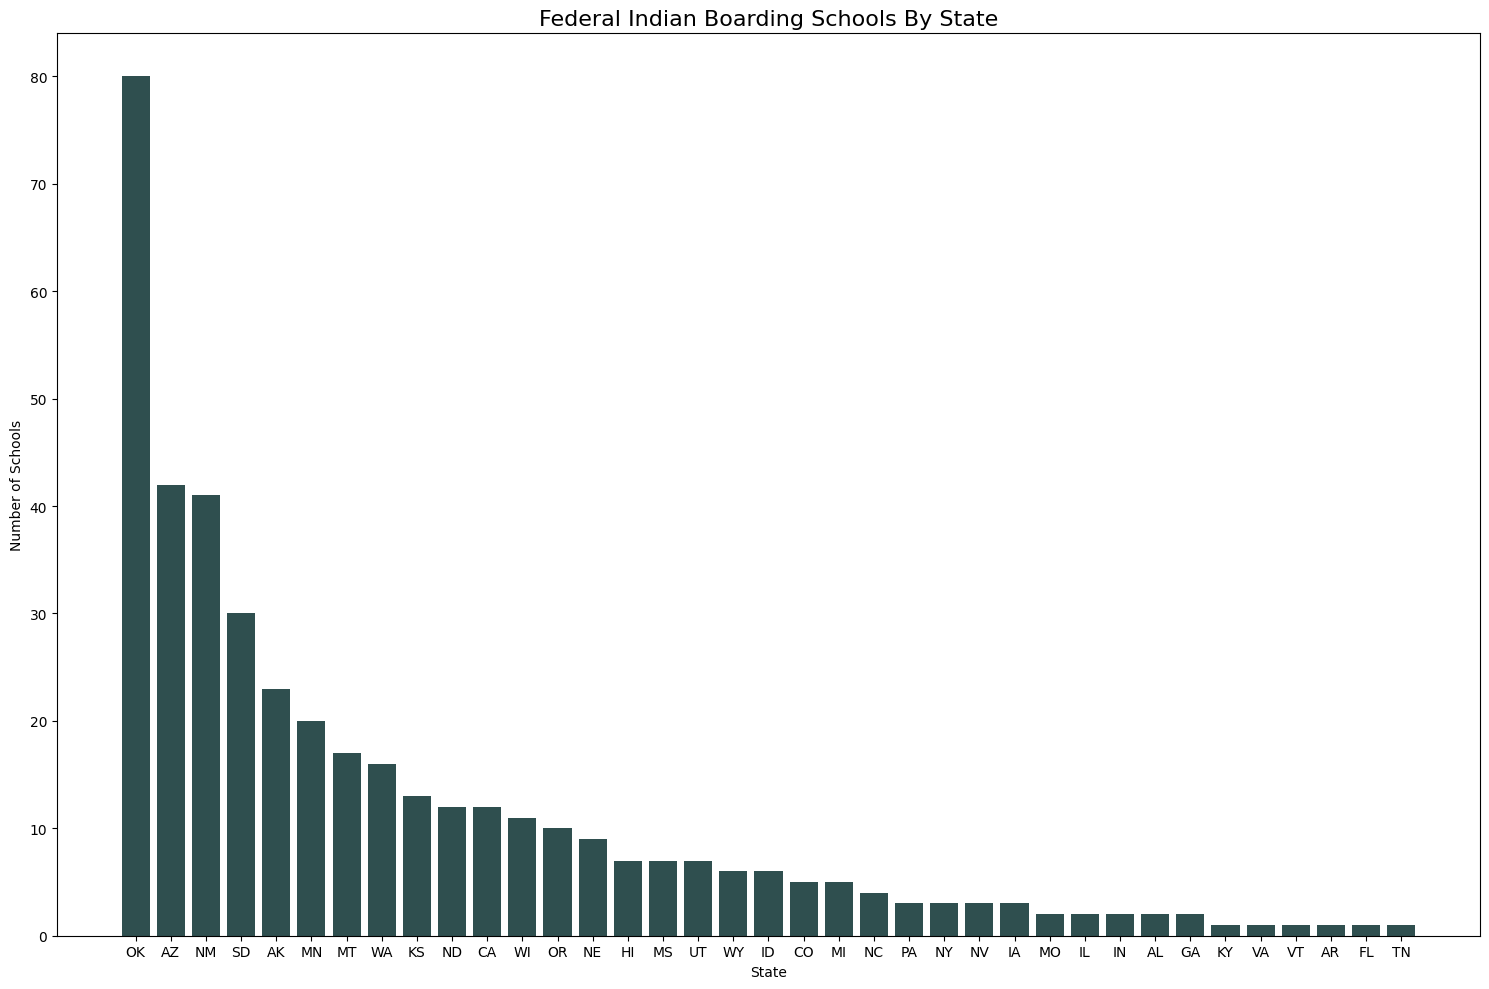

In [40]:
import matplotlib.pyplot as plt
import numpy as np

#have a count for how many schools each state in the dataset had
state_counts = df['State'].value_counts()

#Creating a bar graph to show this easily
plt.figure(figsize = (15, 10))
plt.bar(state_counts.index, state_counts.values, color= 'darkslategrey')

#give it labels and a title
plt.title('Federal Indian Boarding Schools By State', fontsize=16)
plt.xlabel('State')
plt.ylabel('Number of Schools')

#found a new hack- this adjusts spacing for me so nothing get cut off
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

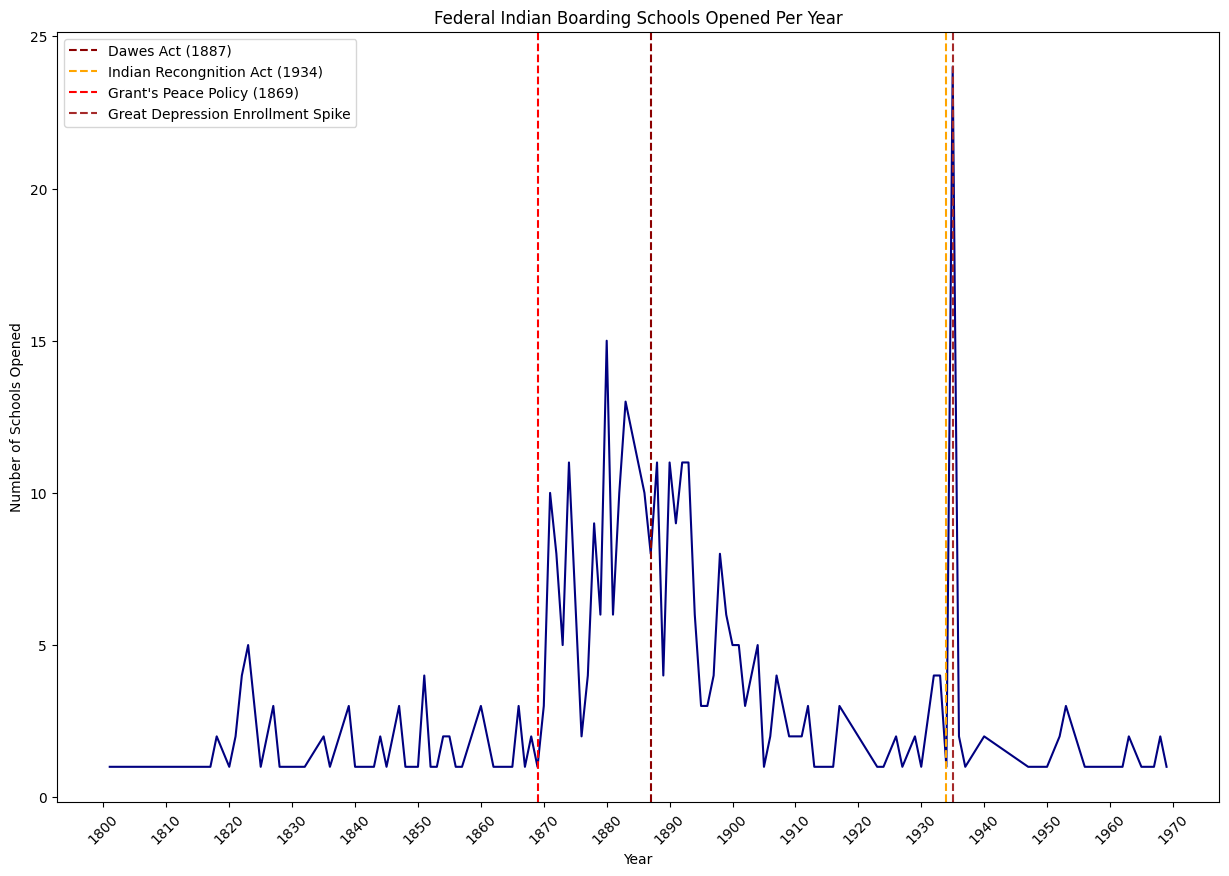

In [42]:
#next is to visualize the years
year_counts = df['open_year'].value_counts().sort_index()

#making a line chart because it will show the spikes in years better
plt.figure(figsize=(15,10))
plt.plot(year_counts.index, year_counts.values, color = 'navy')

#mark Dawe's Act with a vertical line as my historical event
plt.axvline(x = 1887, color = 'darkred', linestyle = '--', label = 'Dawes Act (1887)')

#do the same thing with Indian Recongnition Act 1934
plt.axvline(x = 1934, color = 'orange', linestyle = '--', label = 'Indian Recongnition Act (1934)')

#after visualizing I saw another spike which connects to Ulysses S. Grant’s Peace Policy 1869
#so I am adding another line to show one reason for that spike
plt.axvline(x = 1869, color = 'red', linestyle = '--', label = "Grant's Peace Policy (1869)")

#another thing that surprised my was the spike in 1934/35 so I searched for why
#it might be due to the Great Depression and Native American's decisions to attend these schools for protection
#plotting the reason down like the others
plt.axvline(x = 1935, color = 'brown', linestyle = '--', label = 'Great Depression Enrollment Spike')
#then add labels and titles
plt.title('Federal Indian Boarding Schools Opened Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Schools Opened')
plt.legend()

plt.xticks(np.arange(1800, 1980, 10), rotation=45)

plt.tight_layout
plt.show
